# Experiment 3 — Agent Architectures: The BDI Deliberation Cycle

**AI401 — Expert Systems Lab**

## Aim

To implement a Belief–Desire–Intention agent that revises its beliefs about a
dynamic environment, deliberates over competing desires to commit to an
intention, and executes plans under a chosen commitment strategy, and to
measure how that commitment affects performance as the world changes faster.

## What is built here

| BDI element | Realisation in the Tileworld testbed |
|---|---|
| Beliefs `B` | agent position, the holes currently perceived, the world clock |
| Desires `D` | the holes that exist — options, not commitments |
| Intention `I` | the single hole the agent has committed to filling |
| Plan `π` | the shortest path of moves to that hole |
| `brf(B, p)` | folds the percept into the belief set |
| `options(B, I)` | proposes the holes believed to exist |
| `filter(B, D, I)` | deliberation proper — commits to the nearest, most urgent hole |
| `plan(B, I)` | means–ends reasoning — the move sequence achieving `I` |

The testbed is a 15 × 15 grid on which holes appear at random cells with fixed
probability per **world tick** and expire after a random lifetime. The agent
scores by moving onto a hole. **Effectiveness** is holes filled ÷ holes
appeared, and **world dynamism** `v` is the number of world ticks that elapse
per agent time step. Deliberation is itself charged one agent time step, so the
world does not pause while the agent thinks.

In [ ]:
import random
import matplotlib.pyplot as plt

# ---- world parameters -------------------------------------------------
GRID      = 15            # 15 x 15 grid
HOLE_PROB = 0.03          # probability a hole appears, per world tick
LIFETIME  = (30, 90)      # hole lifetime in world ticks, uniform
BOLD      = 10 ** 9       # gamma larger than any plan == never reconsider

random.seed(0)
print("Tileworld:", GRID, "x", GRID,
      "| hole probability", HOLE_PROB, "per tick",
      "| lifetime", LIFETIME, "ticks")

Tileworld: 15 x 15 | hole probability 0.03 per tick | lifetime (30, 90) ticks


## 1. The environment

The world runs on its own clock. `advance(ticks)` ages every hole, removes the
expired ones and may spawn a new one — this is the "world advances by its own
clock while the action is performed" of step 4 of Algorithm 1.

In [ ]:
class Tileworld:
    """A simplified Tileworld: holes appear and expire on the world clock,
    and are filled by the agent moving onto them."""

    def __init__(self, rng, size=GRID, hole_prob=HOLE_PROB, lifetime=LIFETIME):
        self.rng, self.size = rng, size
        self.hole_prob, self.lifetime = hole_prob, lifetime
        self.tick = 0
        self.holes = {}                                   # (x, y) -> expiry tick
        self.agent = (rng.randrange(size), rng.randrange(size))
        self.appeared = self.filled = self.expired = 0

    def advance(self, ticks):
        """Run the world clock forward: expire old holes, spawn new ones."""
        for _ in range(ticks):
            self.tick += 1
            for cell, expiry in list(self.holes.items()):
                if expiry <= self.tick:                   # lifetime elapsed
                    del self.holes[cell]
                    self.expired += 1
            if self.rng.random() < self.hole_prob:
                c = (self.rng.randrange(self.size), self.rng.randrange(self.size))
                if c not in self.holes and c != self.agent:
                    self.holes[c] = self.tick + self.rng.randint(*self.lifetime)
                    self.appeared += 1

    def move(self, d):
        """One agent move; moving onto a hole fills it."""
        x, y = self.agent
        self.agent = (min(max(x + d[0], 0), self.size - 1),
                      min(max(y + d[1], 0), self.size - 1))
        if self.agent in self.holes:
            del self.holes[self.agent]
            self.filled += 1
            return True
        return False

    def percept(self):
        """The percept p: agent position, live holes, current tick."""
        return {"pos": self.agent, "holes": dict(self.holes), "tick": self.tick}

## 2. The four BDI functions

`options` proposes *every* hole believed to exist — desires are options, not
commitments, and they may conflict. `filter` is deliberation proper: it resolves
that conflict by committing to the nearest hole, ties broken towards the hole
that expires soonest. `achievable` is the separate test used by single-minded
commitment: an intention dies either because the hole is gone or because it can
no longer be reached before it expires.

In [ ]:
def brf(B, p):
    """Belief revision function: fold a percept into the belief set."""
    B = dict(B)
    B.update(p)
    return B


def dist(a, b):
    """Manhattan distance — the cost in moves on this grid."""
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def options(B, I):
    """Desires: the states of affairs the agent would like to bring about."""
    return list(B["holes"].keys())


def filter_(B, D, I):
    """Deliberation: commit to one desire. Nearest first, then most urgent."""
    if not D:
        return None
    return min(D, key=lambda c: (dist(B["pos"], c), B["holes"][c]))


def plan(B, I):
    """Means-ends reasoning: shortest path to the intention."""
    if I is None:
        return []
    (x, y), (tx, ty) = B["pos"], I
    return ([(1 if tx > x else -1, 0)] * abs(tx - x) +
            [(0, 1 if ty > y else -1)] * abs(ty - y))


def achievable(B, I, v):
    """Is the intention still believed achievable? Used by Algorithm 2."""
    if I is None or I not in B["holes"]:
        return False, "hole gone"
    if dist(B["pos"], I) * v > B["holes"][I] - B["tick"]:
        return False, "cannot be reached before it expires"
    return True, ""

## 3. Algorithm 1 (deliberation cycle) and Algorithm 2 (reconsideration)

The two algorithms are interleaved in one loop. The numbered comments map each
block onto the corresponding step of the handout. Note the two places where the
world clock runs: after every action, and again whenever the agent stops to
deliberate.

In [ ]:
def run_bdi(seed, gamma, v, steps=600, trace=False,
            size=GRID, hole_prob=HOLE_PROB, lifetime=LIFETIME):
    """Algorithm 1 + Algorithm 2 under single-minded commitment.

    gamma : reconsideration interval (actions between deliberations)
    v     : world dynamism, world ticks per agent time step
    """
    rng = random.Random(seed)
    w = Tileworld(rng, size, hole_prob, lifetime)
    w.advance(v)
    events, delibs, idle = [], 0, 0

    # --- A1.1  first percept; no intention, empty plan
    B = brf({}, w.percept())
    I, pi, s, t = None, [], 0, 0

    def log(kind, msg):
        if trace:
            events.append(f"[t={t:3d} w={w.tick:4d}] {kind:<7} {msg}")

    while t < steps:
        # --- A1.2  perceive and revise beliefs
        B = brf(B, w.percept())

        # --- A1.3  no intention or exhausted plan -> options, filter, plan
        if I is None or not pi:
            D = options(B, I)
            I = filter_(B, D, I)
            pi = plan(B, I)
            if I is None:                       # D empty: take no action
                idle += 1
                if idle == 1:
                    log("IDLE", "no hole believed to exist; world advances")
                w.advance(v); t += 1
                continue
            idle = 0
            log("COMMIT", f"I <- fill{I}  |plan|={len(pi)}  "
                          f"life left {B['holes'][I] - B['tick']} ticks")

        # --- A1.4  execute the head of the plan; the world advances meanwhile
        a, pi = pi[0], pi[1:]
        did_fill = w.move(a)
        w.advance(v)
        t += 1
        s += 1                                  # --- A2.1  count actions
        B = brf(B, w.percept())

        # --- A1.5  intention achieved -> drop I and pi
        if B["pos"] == I:
            if did_fill:
                log("ACHIEVE", f"filled{I}   (running total {w.filled})")
            else:                               # arrived too late to succeed
                log("DROP", f"I = {I} unachievable (hole expired on arrival)")
            I, pi, s = None, [], 0
            continue

        # --- A2.2  still committed: below the reconsideration interval
        if s < gamma:
            continue

        # --- A2.3  deliberate, and charge it one agent time step
        s = 0
        delibs += 1
        w.advance(v)
        t += 1

        # --- A2.4  re-perceive; drop the intention if it is unachievable
        B = brf(B, w.percept())
        ok, why = achievable(B, I, v)
        if not ok:
            log("DROP", f"I = {I} unachievable ({why})")
            I, pi = None, []
            continue

        # --- A2.5  re-run options and filter; switch to a better option
        best = filter_(B, options(B, I), I)
        if best != I:
            log("SWITCH", f"{I} -> {best}  (distance "
                          f"{dist(B['pos'], I)} -> {dist(B['pos'], best)})")
            I = best
        pi = plan(B, I)                         # re-plan from the new position

    return {"filled": w.filled, "appeared": w.appeared, "delibs": delibs,
            "events": events,
            "eff": w.filled / w.appeared if w.appeared else 0.0}

## 4. Procedure and Result — the event trace

A single run with **γ = 2** (reconsider after every two actions) in a world
running at **v = 2** world ticks per agent step, over 120 agent steps. The trace
shows where the agent commits to an intention, achieves one, drops one that has
become unachievable, and switches to a better option on reconsideration.

In [ ]:
GAMMA_DEMO, V_DEMO, STEPS_DEMO = 2, 2, 120

r = run_bdi(seed=3, gamma=GAMMA_DEMO, v=V_DEMO, steps=STEPS_DEMO, trace=True)

print(f"BDI agent | single-minded commitment | gamma = {GAMMA_DEMO} | "
      f"{V_DEMO} world ticks per agent step | {STEPS_DEMO} agent steps\n")
print("EVENT TRACE")
print("-" * 74)
for e in r["events"]:
    print(e)
print("-" * 74)

for k in ("COMMIT", "ACHIEVE", "DROP", "SWITCH", "IDLE"):
    print(f"{k:<8} events : {sum(k in e for e in r['events'])}")
print()
print(f"holes appeared  : {r['appeared']}")
print(f"holes filled    : {r['filled']}")
print(f"deliberations   : {r['delibs']}  (each charged one agent time step)")
print(f"EFFECTIVENESS   : {r['filled']}/{r['appeared']} = {r['eff']:.3f}")

BDI agent | single-minded commitment | gamma = 2 | 2 world ticks per agent step | 120 agent steps

EVENT TRACE
--------------------------------------------------------------------------
[t=  0 w=   2] IDLE    no hole believed to exist; world advances
[t=  2 w=   6] COMMIT  I <- fill(13, 7)  |plan|=12  life left 46 ticks
[t= 19 w=  40] ACHIEVE filled(13, 7)   (running total 1)
[t= 19 w=  40] COMMIT  I <- fill(12, 1)  |plan|=7  life left 18 ticks
[t= 28 w=  58] DROP    I = (12, 1) unachievable (hole gone)
[t= 28 w=  58] IDLE    no hole believed to exist; world advances
[t= 54 w= 110] COMMIT  I <- fill(6, 9)  |plan|=13  life left 50 ticks
[t= 57 w= 116] SWITCH  (6, 9) -> (9, 9)  (distance 11 -> 8)
[t= 60 w= 122] SWITCH  (9, 9) -> (5, 4)  (distance 6 -> 5)
[t= 67 w= 136] ACHIEVE filled(5, 4)   (running total 2)
[t= 67 w= 136] COMMIT  I <- fill(6, 9)  |plan|=6  life left 24 ticks
[t= 75 w= 152] ACHIEVE filled(6, 9)   (running total 3)
[t= 75 w= 152] COMMIT  I <- fill(9, 9)  |plan|=3  life l

### Comments on the trace

* **COMMIT** — deliberation has resolved the conflict between competing desires
  and turned one of them into an intention. From this point the plan is executed
  without further reasoning, which is exactly what an intention buys: it
  constrains future deliberation.
* **ACHIEVE** — the intention succeeded, so `I` and `π` are dropped and the next
  cycle commits afresh. This is the only condition a *blindly* committed agent
  ever recognises.
* **DROP** — at a reconsideration point the hole was found gone, or too far to
  reach before its expiry. Under **single-minded** commitment this is the second
  exit condition, and it is what stops the agent walking to a target that
  stopped existing several steps ago.
* **SWITCH** — the intention was still achievable, but re-running `options` and
  `filter` found a nearer hole that appeared after the commitment was made. This
  is **open-minded** behaviour: the intention is retained only while it remains
  among the best options.
* The gap between the `t` column and the `w` column is the cost of thinking: two
  world ticks pass per agent step, and the deliberation steps advance `w` without
  advancing the agent towards anything.

## 5. Exercise 1 — Boldness against dynamism

γ is swept over {1, 2, 4, 8, bold} and the world speed over {1, 2, 4, 8} world
ticks per agent action, with effectiveness averaged over 40 random seeds of 600
agent steps each.

In [ ]:
GAMMAS = [1, 2, 4, 8, BOLD]
NAMES  = ["1", "2", "4", "8", "bold"]
SPEEDS = [1, 2, 4, 8]
SEEDS, STEPS = 40, 600

table = {}
for g, n in zip(GAMMAS, NAMES):
    for v in SPEEDS:
        vals = [run_bdi(6000 + s, g, v, STEPS)["eff"] for s in range(SEEDS)]
        table[(n, v)] = sum(vals) / len(vals)

header = "gamma  " + "".join(f"{'v=' + str(v):>10}" for v in SPEEDS)
print(f"Effectiveness (holes filled / holes appeared)")
print(f"mean of {SEEDS} seeds x {STEPS} agent steps\n")
print(header)
print("-" * len(header))
for n in NAMES:
    print(f"{n:<7}" + "".join(f"{table[(n, v)]:>10.3f}" for v in SPEEDS))
print("-" * len(header))
best = {v: max(NAMES, key=lambda n: table[(n, v)]) for v in SPEEDS}
print("best   " + "".join(f"{best[v]:>10}" for v in SPEEDS))

Effectiveness (holes filled / holes appeared)
mean of 40 seeds x 600 agent steps

gamma         v=1       v=2       v=4       v=8
-----------------------------------------------
1           0.916     0.646     0.322     0.132
2           0.961     0.775     0.443     0.194
4           0.972     0.846     0.509     0.216
8           0.978     0.876     0.534     0.199
bold        0.980     0.888     0.508     0.162
-----------------------------------------------
best         bold      bold         8         4


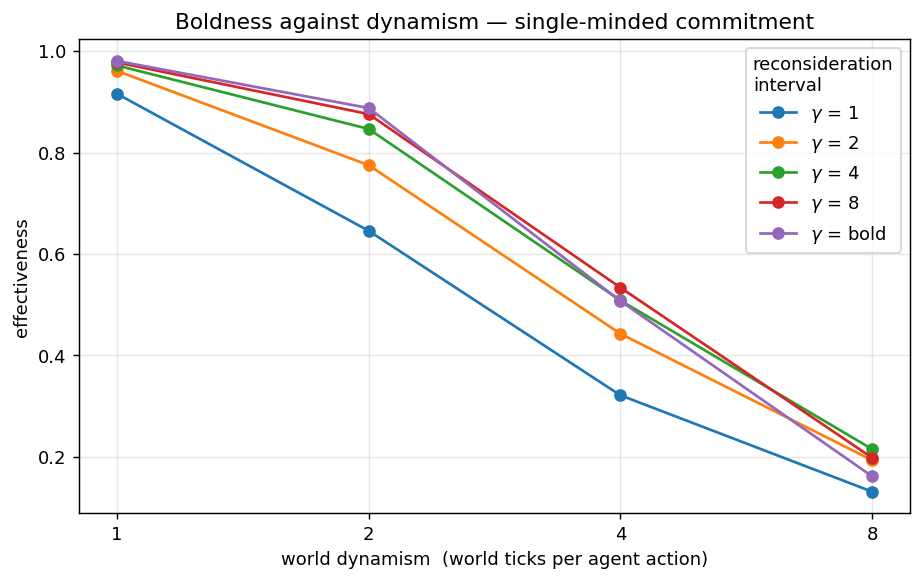

In [ ]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for n in NAMES:
    ax.plot(SPEEDS, [table[(n, v)] for v in SPEEDS], marker="o",
            label=f"$\\gamma$ = {n}")
ax.set_xscale("log", base=2)
ax.set_xticks(SPEEDS)
ax.set_xticklabels(SPEEDS)
ax.set_xlabel("world dynamism  (world ticks per agent action)")
ax.set_ylabel("effectiveness")
ax.set_title("Boldness against dynamism — single-minded commitment")
ax.legend(title="reconsideration\ninterval")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Comments on Exercise 1

**Where the optimum sits.** The best γ falls as the world speeds up:

| world speed v | best γ |
|---|---|
| 1 | bold |
| 2 | bold |
| 4 | 8 |
| 8 | 4 |

**Why the optimum falls.** Deliberation buys information and costs time. In a
slow world an intention formed at commitment time is still the right intention
several steps later, so the information is worth almost nothing while the time
is still charged in full — the bold agent, which never pays, wins. As the world
speeds up, holes expire and appear more often per agent step, so a commitment
decays faster; the expected loss from executing a stale plan grows until it
overtakes the fixed cost of one time step per γ actions, and the optimum slides
down towards cautious values.

**Why both extremes lose at high dynamism.** At γ = 1 the agent deliberates
after every single action, so roughly half of its time steps produce no movement
at all; it is perfectly informed about a world it is too slow to exploit. The
bold agent has the opposite failure: at v = 8 it walks entire plans to holes
that expired at the second step, and its effectiveness at v = 8 (0.162) is even
worse than γ = 2. An intermediate γ pays the overhead rarely enough to keep
moving while still catching dead intentions and better options within a few
steps — which is precisely the Kinny–Georgeff result, that bold agents dominate
in slowly changing worlds and the advantage passes to cautious agents as the
rate of change rises.

**Why deliberation must be charged a time step.** If reconsideration were free,
γ = 1 would dominate everywhere by construction: it has strictly more
information than every other setting and no offsetting cost, so the experiment
would measure nothing. Charging it makes deliberation an action competing with
moving, which is the whole point of a resource-bounded architecture.

## 6. Exercise 2 — A resource-bounded filter

The agent is given a battery of capacity 40 that loses one unit per move and a
charger cell that restores it, and a plan library of two schemas:

* **fill-hole** — applicable only when the battery covers the trip to the hole
  *plus* the return leg to the charger;
* **recharge** — always applicable.

The filter commits to the nearest hole whose precondition holds, and recharges
otherwise. It is compared against a **battery-blind** agent that always chases
the nearest hole.

In [ ]:
CAPACITY = 40


def run_battery(seed, gamma=4, v=2, steps=600, aware=True,
                capacity=CAPACITY, size=GRID, trace=False):
    """aware=True  -> two-schema plan library, filter respects the battery
       aware=False -> battery-blind agent, always chases the nearest hole"""
    rng = random.Random(seed)
    w = Tileworld(rng, size, HOLE_PROB, LIFETIME)
    charger = (size // 2, size // 2)
    w.advance(v)
    B = brf({}, w.percept())
    batt, stranded, recharges, events = capacity, 0, 0, []
    I, pi, s, t, schema = None, [], 0, 0, None

    def log(kind, msg):
        if trace:
            events.append(f"[t={t:3d} b={batt:3d}] {kind:<9} {msg}")

    while t < steps:
        B = brf(B, w.percept())

        if B["pos"] == charger and batt < capacity:
            batt = capacity
            recharges += 1
            log("RECHARGE", "battery restored to full at the charger")
            if schema == "recharge":
                I, pi, schema = None, [], None

        if I is None or not pi:
            D = list(B["holes"].keys())
            if aware:
                # schema fill-hole: precondition is trip + return to charger
                ok = [c for c in D
                      if dist(B["pos"], c) + dist(c, charger) <= batt]
                if ok:
                    I = min(ok, key=lambda c: (dist(B["pos"], c), B["holes"][c]))
                    schema = "fill-hole"
                else:                        # schema recharge: always applicable
                    I, schema = charger, "recharge"
            else:
                I = (min(D, key=lambda c: (dist(B["pos"], c), B["holes"][c]))
                     if D else None)
                schema = "fill-hole"
            pi = plan({"pos": B["pos"]}, I) if I else []
            if not pi:
                w.advance(v); t += 1
                continue
            log("COMMIT", f"{schema} -> {I}  |plan|={len(pi)}")

        if batt <= 0 and B["pos"] != charger:      # flat: cannot move at all
            stranded += 1
            w.advance(v); t += 1
            continue

        a, pi = pi[0], pi[1:]
        did_fill = w.move(a)
        batt -= 1
        w.advance(v); t += 1; s += 1
        B = brf(B, w.percept())

        if B["pos"] == I:
            if schema == "fill-hole":
                log("ACHIEVE" if did_fill else "DROP",
                    f"filled {I}   (total {w.filled})" if did_fill
                    else f"{I} had expired on arrival")
            I, pi, s, schema = None, [], 0, None
            continue

        if s < gamma:
            continue
        s = 0
        w.advance(v); t += 1
        B = brf(B, w.percept())
        if schema == "fill-hole" and I not in B["holes"]:
            log("DROP", f"{I} gone")
            I, pi, schema = None, [], None

    return {"filled": w.filled, "appeared": w.appeared, "stranded": stranded,
            "recharges": recharges, "events": events,
            "eff": w.filled / w.appeared if w.appeared else 0.0}


# a short trace showing the recharge schema being selected
demo = run_battery(7003, steps=140, trace=True)
print("RESOURCE-BOUNDED AGENT — sample trace (b = battery remaining)")
print("-" * 66)
for e in demo["events"][:26]:
    print(e)
print("-" * 66)

RESOURCE-BOUNDED AGENT — sample trace (b = battery remaining)
------------------------------------------------------------------
[t=  0 b= 40] COMMIT    recharge -> (7, 7)  |plan|=9
[t= 11 b= 40] RECHARGE  battery restored to full at the charger
[t= 16 b= 40] COMMIT    fill-hole -> (6, 1)  |plan|=7
[t= 24 b= 33] ACHIEVE   filled (6, 1)   (total 1)
[t= 24 b= 33] COMMIT    recharge -> (7, 7)  |plan|=7
[t= 32 b= 40] RECHARGE  battery restored to full at the charger
[t= 32 b= 40] COMMIT    fill-hole -> (9, 6)  |plan|=3
[t= 35 b= 37] ACHIEVE   filled (9, 6)   (total 2)
[t= 35 b= 37] COMMIT    recharge -> (7, 7)  |plan|=3
[t= 38 b= 40] RECHARGE  battery restored to full at the charger
[t= 57 b= 40] COMMIT    fill-hole -> (12, 3)  |plan|=9
[t= 68 b= 31] ACHIEVE   filled (12, 3)   (total 3)
[t= 68 b= 31] COMMIT    fill-hole -> (6, 4)  |plan|=7
[t= 76 b= 24] ACHIEVE   filled (6, 4)   (total 4)
[t= 76 b= 24] COMMIT    fill-hole -> (12, 11)  |plan|=13
[t= 92 b= 11] ACHIEVE   filled (12, 11)   (to

In [ ]:
rows = []
for aware in (True, False):
    rs = [run_battery(7000 + s, aware=aware) for s in range(30)]
    n = len(rs)
    rows.append((("resource-bounded" if aware else "battery-blind"),
                 sum(r["filled"] for r in rs) / n,
                 sum(r["appeared"] for r in rs) / n,
                 sum(r["eff"] for r in rs) / n,
                 sum(r["stranded"] for r in rs) / n,
                 sum(r["recharges"] for r in rs) / n))

print("Battery capacity 40, charger at the grid centre, "
      "gamma = 4, v = 2, 600 steps, 30 seeds\n")
print(f"{'agent':<18}{'filled':>9}{'appeared':>10}{'eff':>8}"
      f"{'stranded':>10}{'recharges':>11}")
print("-" * 66)
for name, f, a, e, st, rc in rows:
    print(f"{name:<18}{f:>9.2f}{a:>10.2f}{e:>8.3f}{st:>10.2f}{rc:>11.2f}")
print("-" * 66)

Battery capacity 40, charger at the grid centre, gamma = 4, v = 2, 600 steps, 30 seeds

agent                filled  appeared     eff  stranded  recharges
------------------------------------------------------------------
resource-bounded      31.00     36.27   0.855      0.00      18.57
battery-blind          4.70     36.33   0.132    501.70       0.23
------------------------------------------------------------------


### Comments on Exercise 2

The battery-blind agent fills a handful of holes and then spends the
overwhelming majority of the run stranded with a flat battery, because nothing
in it ever asks whether the hole it wants is a hole it can afford. The
resource-bounded agent fills several times as many holes and is never stranded:
it interleaves short filling trips with returns to the charger.

**Which BDI component the fix belongs in.** It belongs in **`filter` — the
deliberation step** (with the schema preconditions supplying the applicability
test). The battery constraint decides *which goal is worth adopting*, and that
is a question about commitment, not about execution.

**Why not the planner.** `plan` performs means–ends reasoning for an intention
that has *already been chosen*: given the goal "fill the hole at (12, 3)", the
shortest path is the shortest path, and no amount of re-planning makes an
unaffordable trip affordable. A planner asked to fix this could only fail or
silently substitute a different goal — and substituting goals *is* deliberation,
so the reasoning would simply have migrated into the wrong module. Keeping it in
`filter` also keeps the architecture honest: the recharge schema is a genuine
competing desire, and the agent is choosing between desires, which is exactly
what `filter` is for.

## 7. Observations

1. **Persistence of intentions.** The DROP and SWITCH events show that an
   intention is more than a preference but less than an irrevocable decision.
   Between reconsideration points the agent does not re-examine its goal at all,
   which is what lets it make progress; at those points it will abandon the goal
   if the world has invalidated it. DROP is the *single-minded* exit condition —
   the intention is believed unachievable. SWITCH is the *open-minded* one — the
   intention is still achievable but is no longer among the best options.
   A blindly committed agent shows neither, and would hold its intention until
   it was achieved.

2. **Why deliberation is charged.** Reconsideration is itself an action with a
   cost. If it were free, more deliberation would be weakly better always, and
   the comparison between commitment strategies would be vacuous. Charging one
   agent time step puts thinking and moving in direct competition, which is what
   makes γ a real design trade-off.

3. **Best γ and how it moved.** In a slow world (v = 1, 2) the bold agent was
   best. As the world was made to change faster the optimum fell to γ = 8 at
   v = 4 and γ = 4 at v = 8, and the bold agent's effectiveness at v = 8 dropped
   below that of γ = 2. Both extremes are beaten by an intermediate value once
   the world moves: γ = 1 is too slow to act, bold is too slow to notice.